EXPERIMENT 7
TEMPORAL DIFFERENCE LEARNING USING TD(0)

AIM
---------------------------------------------------------------------------
To implement Temporal Difference Learning using TD(0)
and estimate the value function of states through
incremental learning from consecutive experiences.

THEORY
---------------------------------------------------------------------------
TD(0) is a model-free Reinforcement Learning method.
It learns from incomplete episodes and updates the
value function after every state transition.

TD(0) Update Equation:
V(S_t) = V(S_t) + alpha * [R_(t+1) + gamma * V(S_(t+1)) - V(S_t)]

TD Error:
delta = R_(t+1) + gamma * V(S_(t+1)) - V(S_t)

TD(0) Training Completed Successfully.
Number of Episodes : 1000
Execution Time : 0.01726 seconds


FINAL STATE VALUES
Start      : 6.668
S1         : 7.500
S2         : 8.237
S3         : 9.612
Goal       : 0.000


TD(0) STATE VALUE SUMMARY
State  Final_Value  Initial_Value
Start        6.668              0
   S1        7.500 

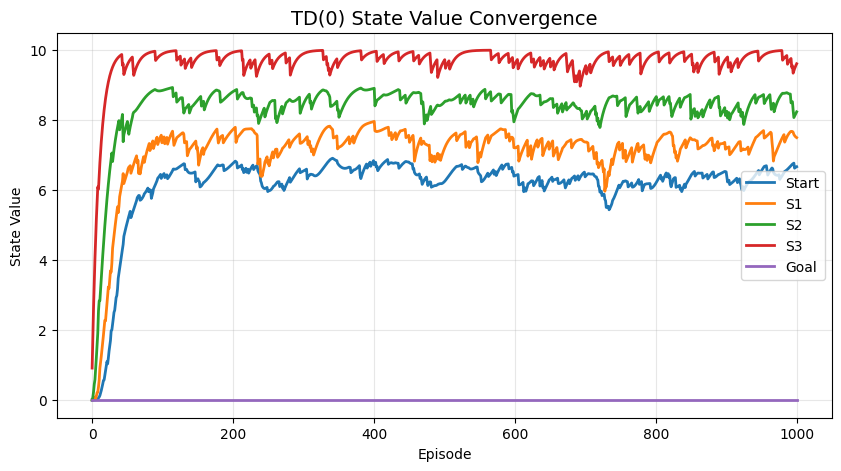

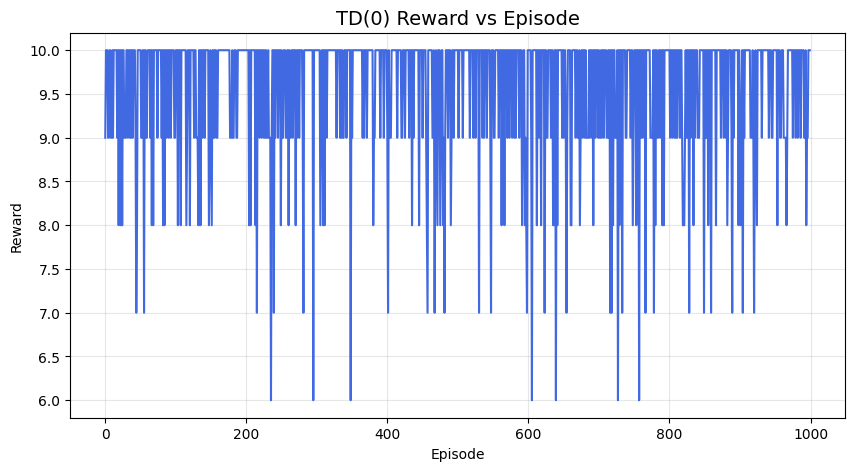

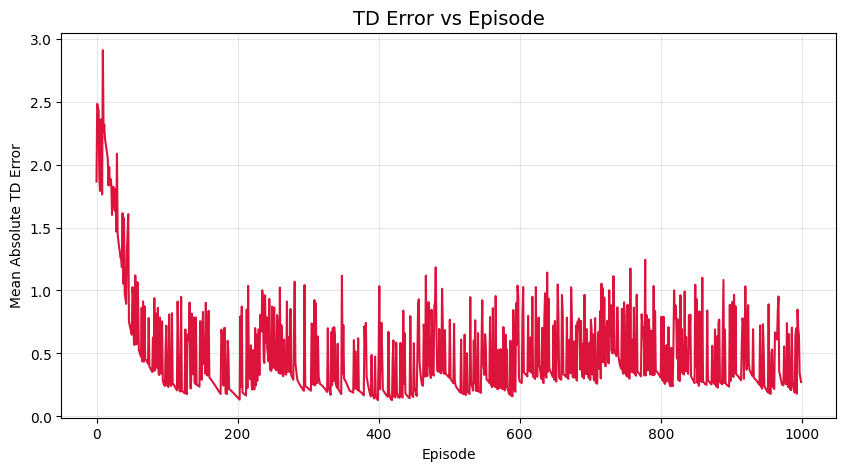

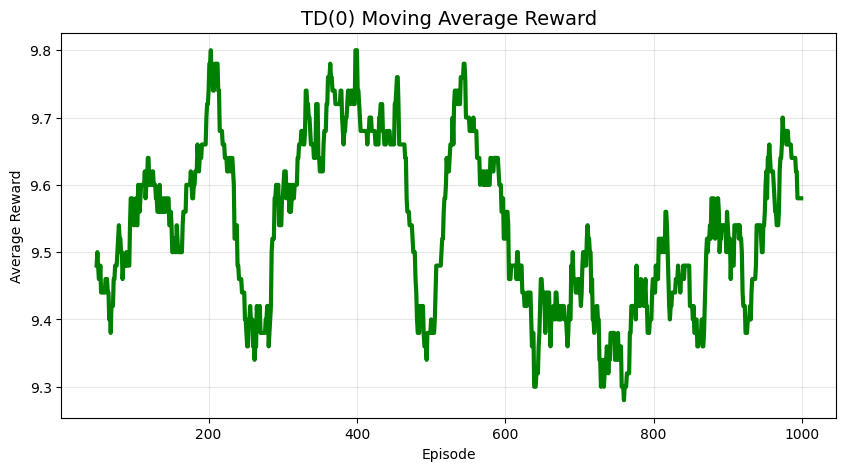

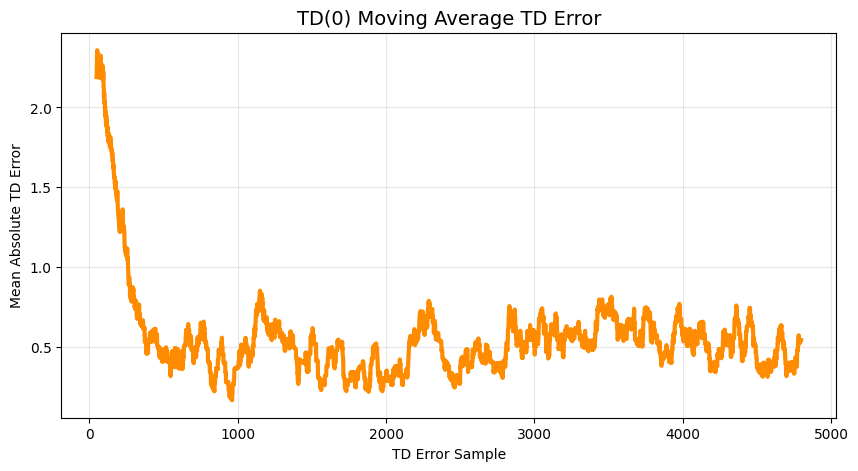

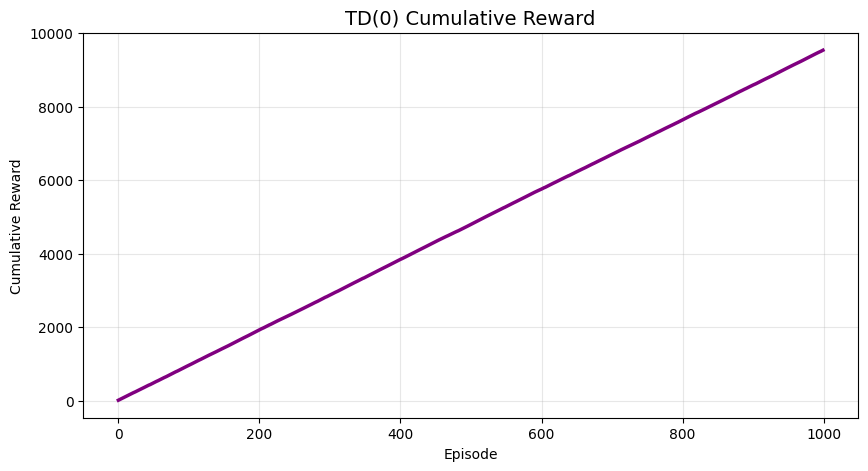

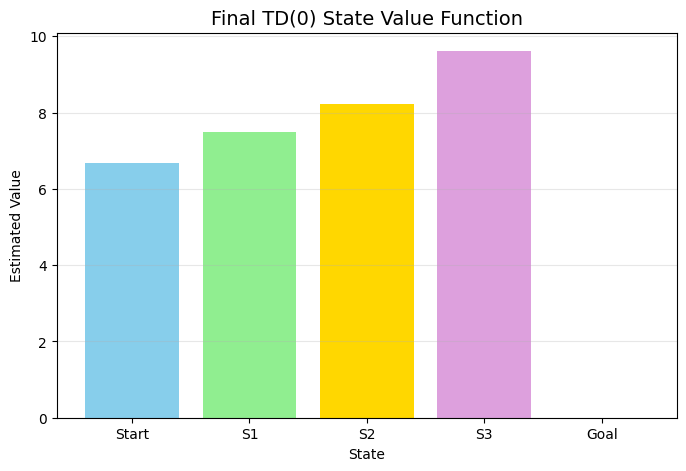

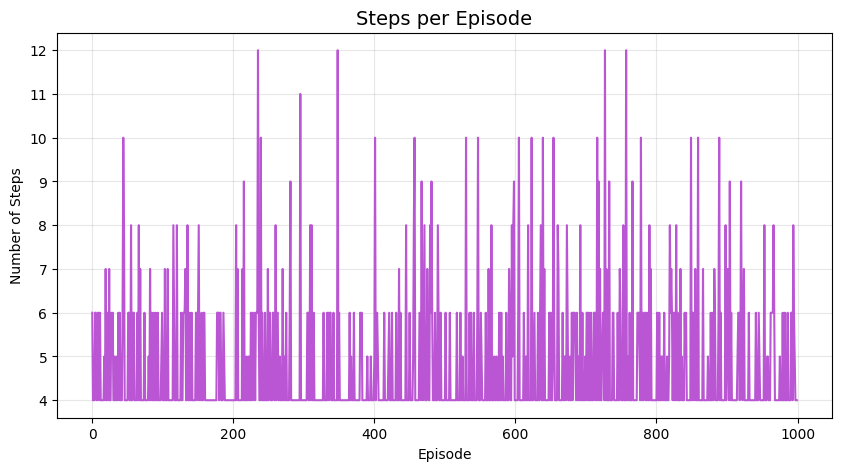

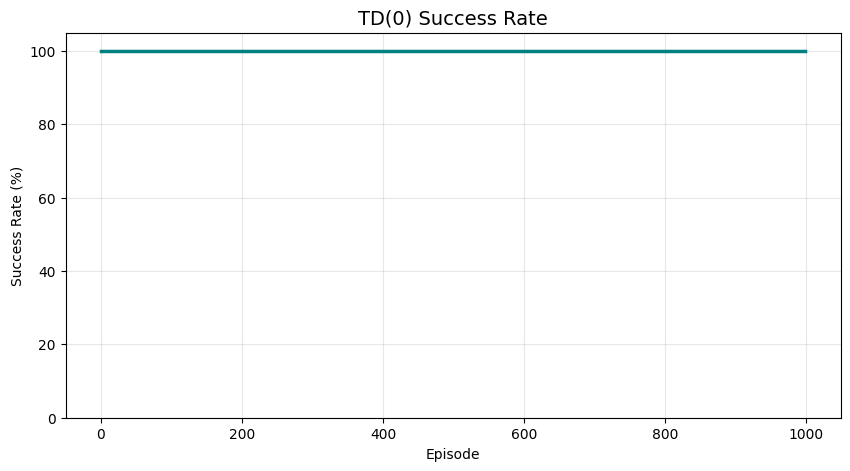

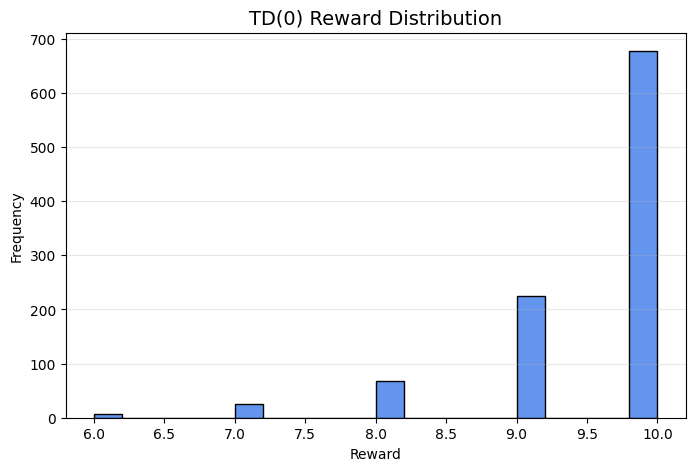



FINAL PERFORMANCE SUMMARY
                   Metric    Value
                Algorithm    TD(0)
       Number of Episodes     1000
    Learning Rate (Alpha)      0.1
  Discount Factor (Gamma)      0.9
           Average Reward    9.539
           Maximum Reward       10
           Minimum Reward        6
Average Absolute TD Error   0.5623
           Final TD Error   0.4709
         Success Rate (%)    100.0
Average Steps per Episode      4.8
 Execution Time (seconds)  0.01726


FINAL STATE VALUE TABLE
State  Final TD(0) Value  State Rank
Start              6.668           4
   S1              7.500           3
   S2              8.237           2
   S3              9.612           1
 Goal              0.000           5


LAST 10 EPISODE RESULTS
 Episode  Reward  Steps  Success  Success_Rate
     991      10      4        1         100.0
     992       9      6        1         100.0
     993       9      6        1         100.0
     994      10      4        1         100.0
     995

In [1]:
# ================================================================
# EXPERIMENT 7
# Temporal Difference Learning using TD(0)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

print("=" * 75)
print("EXPERIMENT 7")
print("TEMPORAL DIFFERENCE LEARNING USING TD(0)")
print("=" * 75)

# ================================================================
# AIM
# ================================================================

print("\nAIM")
print("-" * 75)
print("To implement Temporal Difference Learning using TD(0)")
print("and estimate the value function of states through")
print("incremental learning from consecutive experiences.")

# ================================================================
# THEORY
# ================================================================

print("\nTHEORY")
print("-" * 75)

print("TD(0) is a model-free Reinforcement Learning method.")
print("It learns from incomplete episodes and updates the")
print("value function after every state transition.")

print("\nTD(0) Update Equation:")

print(
    "V(S_t) = V(S_t) + alpha * "
    "[R_(t+1) + gamma * V(S_(t+1)) - V(S_t)]"
)

print("\nTD Error:")

print(
    "delta = R_(t+1) + gamma * V(S_(t+1)) - V(S_t)"
)

# ================================================================
# ENVIRONMENT
# ================================================================

states = [
    "Start",
    "S1",
    "S2",
    "S3",
    "Goal"
]

actions = [
    "Left",
    "Right"
]

n_states = len(states)

n_actions = len(actions)

# ================================================================
# PARAMETERS
# ================================================================

alpha = 0.10

gamma = 0.90

episodes = 1000

max_steps = 20

# ================================================================
# REWARD STRUCTURE
# ================================================================

# Moving toward the goal gives a small positive reward.
# Moving backward gives a negative reward.
# Reaching the goal gives a large positive reward.

def get_next_state(state, action):

    # Start
    if state == 0:

        if action == 0:

            return 0, -1

        else:

            return 1, 0

    # S1
    elif state == 1:

        if action == 0:

            return 0, -1

        else:

            return 2, 0

    # S2
    elif state == 2:

        if action == 0:

            return 1, -1

        else:

            return 3, 0

    # S3
    elif state == 3:

        if action == 0:

            return 2, -1

        else:

            return 4, 10

    # Goal
    else:

        return 4, 0


# ================================================================
# INITIALIZE VALUE FUNCTION
# ================================================================

V = np.zeros(n_states)

# ================================================================
# STATISTICS
# ================================================================

reward_history = []

td_error_history = []

value_history = []

episode_steps = []

success_history = []

# ================================================================
# TD(0) TRAINING
# ================================================================

training_start = time.time()

for episode in range(episodes):

    state = 0

    total_reward = 0

    steps = 0

    success = 0

    for step in range(max_steps):

        steps += 1

        # --------------------------------------------------------
        # Select an action
        # --------------------------------------------------------

        # The environment follows the policy of moving toward
        # the goal most of the time.

        if random.random() < 0.90:

            action = 1

        else:

            action = 0

        # --------------------------------------------------------
        # Take action
        # --------------------------------------------------------

        next_state, reward = get_next_state(
            state,
            action
        )

        # --------------------------------------------------------
        # TD(0) ERROR
        # --------------------------------------------------------

        td_error = (
            reward
            + gamma * V[next_state]
            - V[state]
        )

        # --------------------------------------------------------
        # TD(0) VALUE UPDATE
        # --------------------------------------------------------

        V[state] = (
            V[state]
            + alpha * td_error
        )

        # --------------------------------------------------------
        # Store statistics
        # --------------------------------------------------------

        total_reward += reward

        td_error_history.append(td_error)

        state = next_state

        # --------------------------------------------------------
        # Goal reached
        # --------------------------------------------------------

        if state == 4:

            success = 1

            break

    reward_history.append(total_reward)

    episode_steps.append(steps)

    success_history.append(success)

    value_history.append(V.copy())

training_time = time.time() - training_start

value_history = np.array(value_history)

print("\nTD(0) Training Completed Successfully.")

print("Number of Episodes :", episodes)

print(
    "Execution Time :",
    round(training_time, 5),
    "seconds"
)

# ================================================================
# FINAL STATE VALUES
# ================================================================

print("\n")
print("=" * 75)
print("FINAL STATE VALUES")
print("=" * 75)

for state_name, value in zip(states, V):

    print(
        f"{state_name:10s} : {value:.3f}"
    )
    # ================================================================
# TD(0) RESULTS AND SUMMARY TABLES
# ================================================================

# ------------------------------------------------
# Average Reward
# ------------------------------------------------

average_reward = np.mean(reward_history)

maximum_reward = np.max(reward_history)

minimum_reward = np.min(reward_history)

# ------------------------------------------------
# Average TD Error
# ------------------------------------------------

average_td_error = np.mean(
    np.abs(td_error_history)
)

final_td_error = np.mean(
    np.abs(td_error_history[-100:])
)

# ------------------------------------------------
# Success Rate
# ------------------------------------------------

success_rate = (
    np.mean(success_history) * 100
)

# ------------------------------------------------
# Average Episode Length
# ------------------------------------------------

average_steps = np.mean(
    episode_steps
)

# ================================================================
# STATE VALUE SUMMARY
# ================================================================

state_value_table = pd.DataFrame({

    "State": states,

    "Final_Value": np.round(
        V,
        3
    ),

    "Initial_Value": [
        0,
        0,
        0,
        0,
        0
    ]

})

print("\n")
print("=" * 75)
print("TD(0) STATE VALUE SUMMARY")
print("=" * 75)

print(
    state_value_table.to_string(
        index=False
    )
)

# ================================================================
# PERFORMANCE SUMMARY
# ================================================================

performance_table = pd.DataFrame({

    "Metric": [
        "Episodes",
        "Learning Rate Alpha",
        "Discount Factor Gamma",
        "Average Reward",
        "Maximum Reward",
        "Minimum Reward",
        "Average Absolute TD Error",
        "Final TD Error",
        "Success Rate (%)",
        "Average Episode Steps",
        "Execution Time (seconds)"
    ],

    "Value": [
        episodes,
        alpha,
        gamma,
        round(average_reward, 3),
        round(maximum_reward, 3),
        round(minimum_reward, 3),
        round(average_td_error, 4),
        round(final_td_error, 4),
        round(success_rate, 2),
        round(average_steps, 2),
        round(training_time, 5)
    ]
})

print("\n")
print("=" * 75)
print("TD(0) PERFORMANCE SUMMARY")
print("=" * 75)

print(
    performance_table.to_string(
        index=False
    )
)

# ================================================================
# EPISODE STATISTICS
# ================================================================

episode_table = pd.DataFrame({

    "Episode": np.arange(
        1,
        episodes + 1
    ),

    "Reward": reward_history,

    "Steps": episode_steps,

    "Success": success_history
})

print("\n")
print("=" * 75)
print("EPISODE RESULTS - FIRST 10 EPISODES")
print("=" * 75)

print(
    episode_table.head(10).to_string(
        index=False
    )
)

# ================================================================
# SAVE CSV FILES
# ================================================================

state_value_table.to_csv(
    "TD0_State_Values.csv",
    index=False
)

performance_table.to_csv(
    "TD0_Performance.csv",
    index=False
)

episode_table.to_csv(
    "TD0_Episode_Results.csv",
    index=False
)

# ================================================================
# MOVING AVERAGE REWARD
# ================================================================

window = 50

moving_average_reward = (
    pd.Series(reward_history)
    .rolling(window)
    .mean()
)

# ================================================================
# MOVING AVERAGE TD ERROR
# ================================================================

td_error_series = pd.Series(
    np.abs(td_error_history)
)

moving_average_td_error = (
    td_error_series
    .rolling(50)
    .mean()
)

# ================================================================
# CUMULATIVE REWARD
# ================================================================

cumulative_reward = np.cumsum(
    reward_history
)

# ================================================================
# FINAL VALUE FUNCTION
# ================================================================

print("\n")
print("=" * 75)
print("FINAL TD(0) VALUE FUNCTION")
print("=" * 75)

for i in range(n_states):

    print(
        f"V({states[i]}) = {V[i]:.3f}"
    )

# ================================================================
# BELLMAN TD TARGET
# ================================================================

print("\n")
print("=" * 75)
print("TD(0) LEARNING PARAMETERS")
print("=" * 75)

print("Learning Rate (Alpha) :", alpha)

print("Discount Factor (Gamma) :", gamma)

print("Number of Episodes :", episodes)

print("Maximum Steps per Episode :", max_steps)

print(
    "\nTD Error = R + Gamma * V(Next State) - V(Current State)"
)

print(
    "V(Current State) = V(Current State) + Alpha * TD Error"
)
# ================================================================
# VISUALIZATIONS FOR TD(0)
# ================================================================

# ================================================================
# GRAPH 1
# TD(0) State Value Convergence
# ================================================================

plt.figure(figsize=(10, 5))

for i in range(n_states):

    plt.plot(
        value_history[:, i],
        linewidth=2,
        label=states[i]
    )

plt.title(
    "TD(0) State Value Convergence",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("State Value")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 2
# Reward vs Episode
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    reward_history,
    color="royalblue",
    linewidth=1.5
)

plt.title(
    "TD(0) Reward vs Episode",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 3
# TD Error vs Episode
# ================================================================

# Each episode can have multiple TD errors.
# Calculate the average absolute TD error for each episode.

episode_td_errors = []

position = 0

for steps in episode_steps:

    current_errors = td_error_history[
        position:position + steps
    ]

    if len(current_errors) > 0:

        episode_td_errors.append(
            np.mean(np.abs(current_errors))
        )

    else:

        episode_td_errors.append(0)

    position += steps


plt.figure(figsize=(10, 5))

plt.plot(
    episode_td_errors,
    color="crimson",
    linewidth=1.5
)

plt.title(
    "TD Error vs Episode",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Mean Absolute TD Error")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 4
# Moving Average Reward
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    moving_average_reward,
    color="green",
    linewidth=3
)

plt.title(
    "TD(0) Moving Average Reward",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Average Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 5
# Moving Average TD Error
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    moving_average_td_error,
    color="darkorange",
    linewidth=3
)

plt.title(
    "TD(0) Moving Average TD Error",
    fontsize=14
)

plt.xlabel("TD Error Sample")

plt.ylabel("Mean Absolute TD Error")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 6
# Cumulative Reward
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    cumulative_reward,
    color="purple",
    linewidth=2.5
)

plt.title(
    "TD(0) Cumulative Reward",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Cumulative Reward")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 7
# Final State Value Function
# ================================================================

plt.figure(figsize=(8, 5))

plt.bar(
    states,
    V,
    color=[
        "skyblue",
        "lightgreen",
        "gold",
        "plum",
        "salmon"
    ]
)

plt.title(
    "Final TD(0) State Value Function",
    fontsize=14
)

plt.xlabel("State")

plt.ylabel("Estimated Value")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ================================================================
# GRAPH 8
# Steps per Episode
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    episode_steps,
    color="mediumorchid",
    linewidth=1.5
)

plt.title(
    "Steps per Episode",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Number of Steps")

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 9
# Success Rate
# ================================================================

success_rate_history = []

for i in range(
    1,
    len(success_history) + 1
):

    current_success_rate = (
        np.mean(
            success_history[:i]
        ) * 100
    )

    success_rate_history.append(
        current_success_rate
    )


plt.figure(figsize=(10, 5))

plt.plot(
    success_rate_history,
    color="teal",
    linewidth=2.5
)

plt.title(
    "TD(0) Success Rate",
    fontsize=14
)

plt.xlabel("Episode")

plt.ylabel("Success Rate (%)")

plt.ylim(0, 105)

plt.grid(True, alpha=0.3)

plt.show()


# ================================================================
# GRAPH 10
# Reward Distribution
# ================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    reward_history,
    bins=20,
    color="cornflowerblue",
    edgecolor="black"
)

plt.title(
    "TD(0) Reward Distribution",
    fontsize=14
)

plt.xlabel("Reward")

plt.ylabel("Frequency")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()
# ================================================================
# EXPERIMENT 7 - FINAL RESULTS AND CONCLUSION
# ================================================================

# ================================================================
# FINAL PERFORMANCE METRICS
# ================================================================

final_performance = pd.DataFrame({

    "Metric": [
        "Algorithm",
        "Number of Episodes",
        "Learning Rate (Alpha)",
        "Discount Factor (Gamma)",
        "Average Reward",
        "Maximum Reward",
        "Minimum Reward",
        "Average Absolute TD Error",
        "Final TD Error",
        "Success Rate (%)",
        "Average Steps per Episode",
        "Execution Time (seconds)"
    ],

    "Value": [
        "TD(0)",
        episodes,
        alpha,
        gamma,
        round(average_reward, 3),
        round(maximum_reward, 3),
        round(minimum_reward, 3),
        round(average_td_error, 4),
        round(final_td_error, 4),
        round(success_rate, 2),
        round(average_steps, 2),
        round(training_time, 5)
    ]
})

print("\n")
print("=" * 75)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 75)

print(
    final_performance.to_string(
        index=False
    )
)

# ================================================================
# STATE VALUE RESULT TABLE
# ================================================================

final_state_values = pd.DataFrame({

    "State": states,

    "Final TD(0) Value": np.round(
        V,
        3
    ),

    "State Rank": (
        np.argsort(
            np.argsort(-V)
        ) + 1
    )
})

print("\n")
print("=" * 75)
print("FINAL STATE VALUE TABLE")
print("=" * 75)

print(
    final_state_values.to_string(
        index=False
    )
)

# ================================================================
# EPISODE SUMMARY
# ================================================================

episode_summary = pd.DataFrame({

    "Episode": np.arange(
        1,
        episodes + 1
    ),

    "Reward": np.round(
        reward_history,
        3
    ),

    "Steps": episode_steps,

    "Success": success_history,

    "Success_Rate": np.round(
        success_rate_history,
        2
    )
})

print("\n")
print("=" * 75)
print("LAST 10 EPISODE RESULTS")
print("=" * 75)

print(
    episode_summary.tail(10).to_string(
        index=False
    )
)

# ================================================================
# SAVE ALL CSV FILES
# ================================================================

final_performance.to_csv(
    "TD0_Final_Performance.csv",
    index=False
)

final_state_values.to_csv(
    "TD0_Final_State_Values.csv",
    index=False
)

episode_summary.to_csv(
    "TD0_Episode_Summary.csv",
    index=False
)

# ================================================================
# COMBINED SUMMARY TABLE
# ================================================================

combined_summary = pd.DataFrame({

    "Parameter": [
        "Algorithm",
        "Episodes",
        "Alpha",
        "Gamma",
        "Average Reward",
        "Average TD Error",
        "Final TD Error",
        "Success Rate",
        "Average Steps",
        "Execution Time"
    ],

    "Result": [
        "TD(0)",
        episodes,
        alpha,
        gamma,
        round(average_reward, 3),
        round(average_td_error, 4),
        round(final_td_error, 4),
        str(round(success_rate, 2)) + "%",
        round(average_steps, 2),
        str(round(training_time, 5)) + " seconds"
    ]
})

print("\n")
print("=" * 75)
print("COMBINED SUMMARY TABLE")
print("=" * 75)

print(
    combined_summary.to_string(
        index=False
    )
)

combined_summary.to_csv(
    "TD0_Complete_Summary.csv",
    index=False
)

# ================================================================
# FINAL RESULT
# ================================================================

print("\n")
print("=" * 75)
print("FINAL RESULT")
print("=" * 75)

print("TD(0) successfully learned the value function.")

print(
    "\nLearned State Values:"
)

for i in range(n_states):

    print(
        f"V({states[i]}) = {V[i]:.3f}"
    )

print(
    "\nAverage Reward :",
    round(average_reward, 3)
)

print(
    "Average TD Error :",
    round(average_td_error, 4)
)

print(
    "Final TD Error :",
    round(final_td_error, 4)
)

print(
    "Success Rate :",
    round(success_rate, 2),
    "%"
)

# ================================================================
# INTERPRETATION
# ================================================================

print("\n")
print("=" * 75)
print("INTERPRETATION")
print("=" * 75)

print(
    "1. TD(0) updates the value of a state after every transition."
)

print(
    "2. The TD error measures the difference between the current"
)

print(
    "   value estimate and the one-step Bellman target."
)

print(
    "3. Repeated updates allow the value estimates to converge."
)

print(
    "4. A lower TD error indicates improved value estimation."
)

print(
    "5. The Goal state receives the highest long-term value."
)

# ================================================================
# CONCLUSION
# ================================================================

print("\n")
print("=" * 75)
print("CONCLUSION")
print("=" * 75)

print(
    "Temporal Difference Learning using TD(0) was successfully"
)

print(
    "implemented using Python."
)

print(
    "The algorithm learned the state-value function incrementally"
)

print(
    "from consecutive state transitions without requiring a model"
)

print(
    "of the environment."
)

print(
    "The TD error was used to update the value estimates after"
)

print(
    "each transition."
)

print(
    "The convergence graph demonstrates how the state values"
)

print(
    "change during learning."
)

print(
    "Therefore, TD(0) provides an efficient model-free method"
)

print(
    "for estimating state values in Reinforcement Learning."
)

# ================================================================
# FILES GENERATED
# ================================================================

print("\n")
print("=" * 75)
print("FILES GENERATED")
print("=" * 75)

print("1. TD0_State_Values.csv")
print("2. TD0_Performance.csv")
print("3. TD0_Episode_Results.csv")
print("4. TD0_Final_Performance.csv")
print("5. TD0_Final_State_Values.csv")
print("6. TD0_Episode_Summary.csv")
print("7. TD0_Complete_Summary.csv")

print("\n")
print("=" * 75)
print("EXPERIMENT 7 COMPLETED SUCCESSFULLY")
print("=" * 75)